# CLO Equity Yield — a quantitative teardown 🔬
### Total-return vs price-only distribution decomposition (HAC *t*) · TR spread vs HYG · NW-HAC alpha vs a credit/equity benchmark · lag & subperiod robustness · crisis autopsies · a synthetic faithful-engine control

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Return_OF_capital%3F: Confirmed](https://img.shields.io/badge/Return_OF_capital%3F-Confirmed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim — *"ECC/OXLC pay ~15% of real CLO-equity cash flow"* — is unusual for this desk in that its central number is **true** (and understated); the study's job is to measure what the payout costs, whether any *surplus* exists over the one-click alternative, and how much of the distribution is a return OF capital.

> ⚠️ **Data + survivorship note.** Double yfinance tape (auto-adjusted total-return AND raw split-adjusted price-only; OXLC's 2025-09 1-for-5 reverse split handled on both legs) for ECC / OXLC / HYG / SPY / BIL; ECC window 2014-11-30 → 2026-06-30 (140 months), OXLC from 2011-02 (185), as-of 2026-06-30. **There is no index fund for CLO equity — the listed category is these two survivors**, so the panel is survivor-tilted by construction (the category's full economics are, if anything, worse). Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (fingerprint `366d9cf7d356`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from clo_equity_yield import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    TR, PX = data.load_real()
    MTR, MPX = st.aligned_monthly(TR, PX, ["ECC", "OXLC", "HYG", "SPY", "BIL"])
else:
    TR = PX = MTR = MPX = None
print("real CLO-fund cache present:", HAVE_REAL,
      "| months (ECC window):", (0 if MTR is None else len(MTR)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2014-11-30', 'end': '2026-06-30', 'n_months': 140, 'years': 11.7, 'as_of': '2026-06-30', 'fingerprint': '366d9cf7d356', 'decomp': {'ECC': (140, 133.3, 17.22, 15.33, 1.75, -13.46, 122.5, 18.5), 'OXLC': (185, 147.34, 19.19, 15.35, 2.52, -14.38, 146.7, 9.1)}, 'perf': {'ECC': (1.75, 24.63, 0.14, -59.37), 'OXLC': (0.64, 32.29, 0.14, -61.08), 'HYG': (4.16, 7.21, 0.34, -15.25), 'SPY': (13.78, 14.97, 0.82, -23.93), 'BIL': (1.88, 0.57, None, -0.16)}, 'excess': {'ECC': (28.47, 0.43), 'OXLC': (47.51, 0.81)}, 'spread': {'ECC': (7.87, 0.95, 0.13, 140, 1.75, 4.16), 'OXLC': (17.78, 2.15, 0.34, 185, 2.52, 4.8)}, 'race': {'ECC': (-18.84, -2.24, -0.33, 1.42, 1.63, 0.18, 0.8, 0.25, 1.75, 6.98, -59.4, -25.5, -0.34), 'OXLC': (-33.55, -3.95, -0.66, 1.24, 2.81, 0.41, 2.59, 0.24, 2.52, 10.6, -61.1, -28.2, -0.71)}, 'robust_lags': {'ECC': [(3, 0.14, -0.36), (6, 0.13, -0.33), (12, 0.13, -0.3)], 'OXLC': [(3, 0.36, -0.67), (6, 0.34, -0.66), (12, 0.33, -0.65)]}, 'sub': {'2016-01+': {'ECC': (17.67, 14.9, 2.44, -13.19, 6.53, 0.1, 126), 'OXLC': (21.17, 14.0, 3.06, -15.25, 30.75, 0.43, 126)}, '2020-07+': {'ECC': (19.86, 11.1, 7.98, -10.23, 38.29, 0.43, 72), 'OXLC': (21.04, 9.7, 5.3, -13.25, 32.98, 0.34, 72)}}, 'roc': {'ECC': (17.22, -13.46, 78.1, 1.75), 'OXLC': (19.19, -14.38, 74.9, 2.52)}, 'crises': [('Credit crunch 2015-16', -29.7, -57.1, -13.4, -13.0), ('Q4 2018', -25.6, -23.4, -6.4, -19.3), ('COVID 2020', -66.1, -73.8, -22.0, -33.7), ('Rate shock 2022', -19.1, -36.8, -15.5, -24.5)], 'syn': [(0.0, 0.0, 0.85, 0.33, 33.4, 0.99), (120.0, -150.0, 120.85, 47.36, -116.6, -3.44)]}


real CLO-fund cache present: True | months (ECC window): 140


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `REAL` | Distribution component **+133.30 bps/mo (+17.22%/yr)** on ECC at **HAC t = +15.33** (OXLC +19.19%/yr, t = +15.35); the surplus over plain HYG is **zero** (spread HAC t = +0.13 / +0.34). |
| **Tradability** | `MIRAGE` | TR CAGR **+1.75% / +2.52%/yr** (excess over bills t = +0.43 / +0.81 — cash), maxDD **-59% / -61%**, alpha vs HYG+SPY **-2.2% / -4.0%/yr** (t = -0.33 / -0.66), and the beta-matched copy compounded 5-8 pp/yr faster at half the drawdown. |
| **Return OF capital?** | `CONFIRMED` | **78.1%** (ECC) / **74.9%** (OXLC) of the payout stream offset one-for-one by price erosion; $100 of capital → **$18.5 / $9.1** price-only. |

> 💡 In plain words: the coupon is real and enormous; the wrapper converts it into T-bill money at first-loss-credit risk. Real carry, mirage package — the fifth (and most extreme) member of the family: [340](../../340-bank-loans/README.md), [341](../../341-mlp-pipelines/README.md), [342](../../342-bdc-yield/README.md), [611](../../611-mreit-carry/README.md).

## 1 · The claim, steelmanned

Let $r^{TR}_{t}$ and $r^{PX}_{t}$ be a fund's monthly total-return and price-only returns. The **distribution component** (the coupon the pitch sells) is

$$c_t = r^{TR}_t - r^{PX}_t \ge 0,$$

and the claim decomposes into:

- **H₁ (the payout exists).** $\bar{c} \approx$ 15%/yr, significant under a serial-correlation-robust test.
- **H₂ (the payout buys a surplus).** The fund's *total* return beats the one-click credit alternative: the TR spread vs HYG has a positive HAC $t$, and the NW-HAC $\alpha \ge 0$ in $r^{fund}_t - r^f_t = \alpha + \beta_{HYG}(r^{HYG}_t - r^f_t) + \beta_{SPY}(r^{SPY}_t - r^f_t) + \varepsilon_t$.
- **H₃ (return ON capital).** The income is spendable without consuming capital: price-only CAGR $\approx 0$.

We find **H₁ confirmed** (t ≈ 15.3 on both funds, payout 17-19%/yr), **H₂ rejected as zero** (spread vs HYG t = +0.13 / +0.34; α t = -0.33 / -0.66), **H₃ busted** (price legs -13.5% / -14.4%/yr — ~75-78% of the payout is capital).

## 2 · So what? — what rides on each answer

A CLO-equity CEF is double leverage on first-loss credit: the equity tranche is the residual of a ~10× levered loan pool (it absorbs the first defaults), and the fund adds its own preferred/note leverage plus management-and-incentive fees on *gross* assets — total expense ratios run high-single to low-double-digit percent of NAV in the funds' own reports. If H₂ held, retail would have cheap access to the institutional CLO-equity premium documented by Cordell-Roberts-Schwert (2023) — genuinely interesting. If only H₁ holds, the sector is the loan-securitization flavour of the desk's packaged-carry family: a real coupon financed by NAV erosion, with board-declared distributions (Rule 19a-1 return-of-capital notices are the accounting tell) doing the marketing. The decisive statistics are the **HAC t of the TR spread vs HYG** and the **NW-HAC alpha** — never the yield.

## 3 · How we'd know — the protocol

- **Tape.** yfinance daily, downloaded twice (`auto_adjust=True/False`); monthly resample, partial months dropped; ECC window 2014-11-30 → 2026-06-30 (140 months), OXLC 2011-02 → (185). As-of 2026-06-30, fingerprint `366d9cf7d356`.
- **Payout.** $c_t = r^{TR}_t - r^{PX}_t$; mean tested with Newey-West HAC t (6 lags; 3/12 as robustness) — payout streams are serially correlated.
- **Headline.** TR spread vs HYG (both legs total return, same account, no timing), HAC t, each fund on its own full window.
- **Benchmark.** NW-HAC OLS of excess returns on HYG + SPY excess returns (excess-on-excess, so α is a risk-adjusted spread). Full-sample betas — a risk-decomposition benchmarking choice, stated openly; nothing is a timed rule.
- **Execution/costs.** Passive buy-and-hold decomposition: entry at the first month-end close (the one documented lag — there is no timing signal). Two one-way trades / 11.7 yrs at ~10 bps ≈ 1.7 bps/yr; the funds' 9-13%/yr fee+leverage drag is inside the tape.
- **Crises.** Fixed documented windows (2015-16 crunch, Q4-2018, COVID, 2022); peak-to-trough TR drawdowns on the daily tape.
- **Positive control.** Synthetic world with planted `carry` and `alpha` knobs; the null (0, 0) must stay silent.

## 4 · The teardown

### 4a · The distribution decomposition — H₁

Monthly distribution component per fund, with its HAC *t*; against it, the price-only CAGR it rode on.

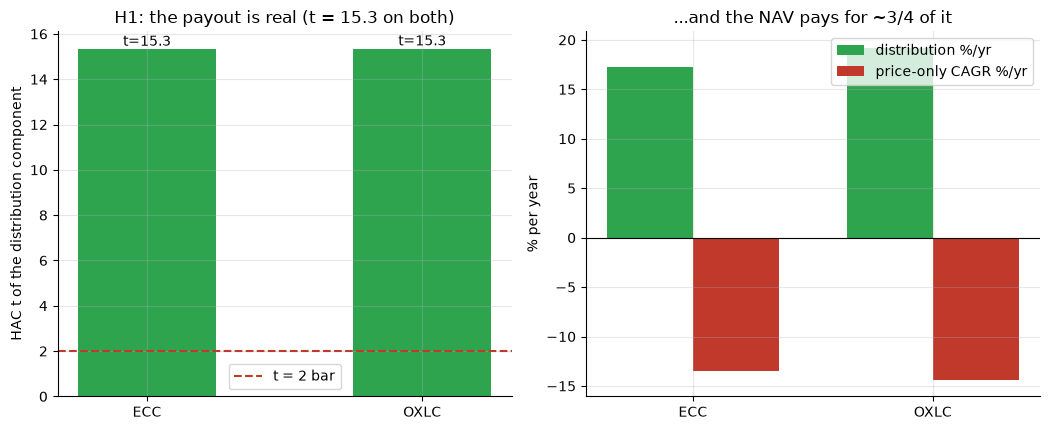

 ECC: dist +133.30 bps/mo = +17.22%/yr (HAC t +15.33) | TR +1.75%/yr  PX -13.46%/yr  (n=140)
OXLC: dist +147.34 bps/mo = +19.19%/yr (HAC t +15.35) | TR +2.52%/yr  PX -14.38%/yr  (n=185)


In [2]:
names = ['ECC', 'OXLC']
if HAVE_REAL:
    rows = []
    for nm in names:
        mtr, mpx = st.aligned_monthly(TR, PX, [nm, 'HYG', 'SPY', 'BIL'])
        dd = st.decompose(mtr, mpx, nm)
        rows.append((nm, dd['dist_bps_mo'], dd['dist_ann_pct'], dd['dist_hac_t'],
                     dd['tr_cagr_pct'], dd['px_cagr_pct'], dd['n_months']))
else:
    rows = [(nm, R['decomp'][nm][1], R['decomp'][nm][2], R['decomp'][nm][3],
             R['decomp'][nm][4], R['decomp'][nm][5], R['decomp'][nm][0]) for nm in names]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.6, 4.4))
a1.bar(names, [r[3] for r in rows], color=GREEN, width=.5)
a1.axhline(2, ls='--', c=RED, label='t = 2 bar')
for i, r in enumerate(rows): a1.annotate(f't={r[3]:.1f}', (i, r[3]), ha='center', va='bottom')
a1.set_ylabel('HAC t of the distribution component')
a1.set_title('H1: the payout is real (t = 15.3 on both)')
a1.legend()
a2.bar(np.arange(2) - .18, [r[2] for r in rows], .36, color=GREEN, label='distribution %/yr')
a2.bar(np.arange(2) + .18, [r[5] for r in rows], .36, color=RED, label='price-only CAGR %/yr')
a2.axhline(0, c='k', lw=.8)
a2.set_xticks(np.arange(2)); a2.set_xticklabels(names)
a2.set_ylabel('% per year'); a2.set_title('...and the NAV pays for ~3/4 of it'); a2.legend()
plt.tight_layout(); plt.show()
for r in rows:
    print(f'{r[0]:>4}: dist {r[1]:+.2f} bps/mo = {r[2]:+.2f}%/yr (HAC t {r[3]:+.2f}) | '
          f'TR {r[4]:+.2f}%/yr  PX {r[5]:+.2f}%/yr  (n={r[6]})')

> 💡 In plain words: the coupon is as real as statistics gets — ECC paid **+17.22%/yr** at **t = 15.3**, OXLC **+19.19%/yr** at **t = 15.3** — and both price legs eroded **−13 to −14%/yr**. The machine pays its coupon mostly out of its own NAV: the financed-by-price share is **78.1%** (ECC) and **74.9%** (OXLC) — H₃'s answer, measured (the third-axis table in [`docs/results.md`](../docs/results.md)).

### 4b · The headline test — TR spread vs HYG, and the NW-HAC alpha (H₂)

Left: the HAC *t* of each fund's monthly total-return spread over plain HYG (own full windows). Right: the beta-matched HYG+SPY copy of ECC, compounding past it.

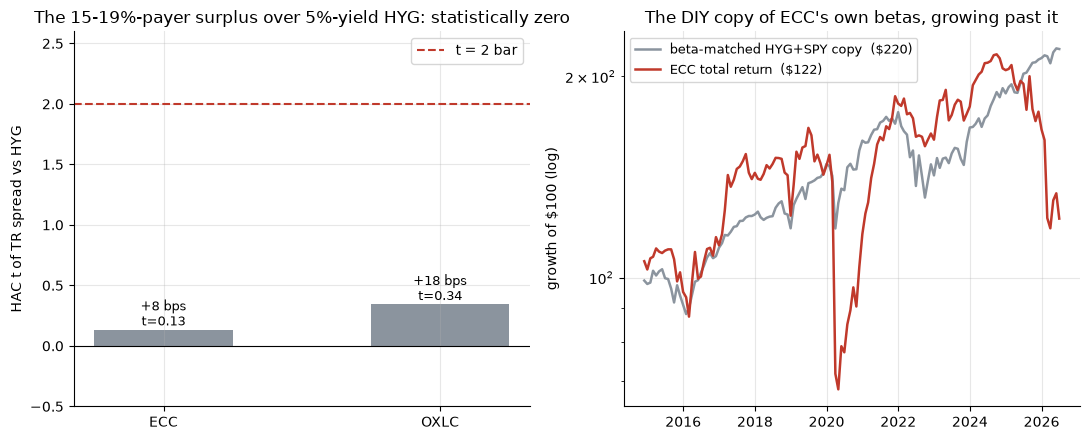

 ECC: spread vs HYG +7.87 bps/mo  HAC t = +0.13
OXLC: spread vs HYG +17.78 bps/mo  HAC t = +0.34
 ECC: alpha  -18.84 bps/mo (t -0.33)  b_HYG +1.42  b_SPY +0.18  | CAGR +1.75%/yr vs bench +6.98%/yr
OXLC: alpha  -33.55 bps/mo (t -0.66)  b_HYG +1.24  b_SPY +0.41  | CAGR +2.52%/yr vs bench +10.60%/yr


In [3]:
names = ['ECC', 'OXLC']
if HAVE_REAL:
    srows, arows = [], []
    for nm in names:
        mtr, _ = st.aligned_monthly(TR, PX, [nm, 'HYG', 'SPY', 'BIL'])
        s = st.tr_spread_vs(mtr, nm)
        br = st.benchmark_race(mtr, nm)
        srows.append((nm, s['spread_bps_mo'], s['spread_t']))
        arows.append((nm, br['alpha_bps_mo'], br['t_alpha'], br['beta_HYG'], br['beta_SPY'],
                      br['name_cagr_pct'], br['bench_cagr_pct']))
    mtr_e, _ = st.aligned_monthly(TR, PX, ['ECC', 'HYG', 'SPY', 'BIL'])
    br_e = st.benchmark_race(mtr_e, 'ECC')
    w_e = (1 + mtr_e['ECC']).cumprod() * 100
    w_b = (1 + br_e['bench_series']).cumprod() * 100
else:
    srows = [(nm, R['spread'][nm][0], R['spread'][nm][2]) for nm in names]
    arows = [(nm, R['race'][nm][0], R['race'][nm][2], R['race'][nm][3], R['race'][nm][5],
              R['race'][nm][8], R['race'][nm][9]) for nm in names]
    w_e = w_b = None
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.0, 4.5))
a1.bar([r[0] for r in srows], [r[2] for r in srows], color=GREY, width=.5)
a1.axhline(2, ls='--', c=RED, label='t = 2 bar'); a1.axhline(0, c='k', lw=.8)
for i, r in enumerate(srows):
    a1.annotate(f'{r[1]:+.0f} bps\nt={r[2]:.2f}', (i, r[2]), ha='center', va='bottom', fontsize=9)
a1.set_ylim(-0.5, 2.6)
a1.set_ylabel('HAC t of TR spread vs HYG')
a1.set_title('The 15-19%-payer surplus over 5%-yield HYG: statistically zero')
a1.legend()
if w_e is not None:
    a2.plot(w_b, c=GREY, lw=1.8, label=f'beta-matched HYG+SPY copy  (${w_b.iloc[-1]:.0f})')
    a2.plot(w_e, c=RED, lw=1.8, label=f'ECC total return  (${w_e.iloc[-1]:.0f})')
    a2.set_yscale('log'); a2.legend(fontsize=9)
    a2.set_title('The DIY copy of ECC\'s own betas, growing past it')
    a2.set_ylabel('growth of $100 (log)')
plt.tight_layout(); plt.show()
for r in srows: print(f'{r[0]:>4}: spread vs HYG {r[1]:+.2f} bps/mo  HAC t = {r[2]:+.2f}')
for r in arows:
    print(f'{r[0]:>4}: alpha {r[1]:+7.2f} bps/mo (t {r[2]:+.2f})  b_HYG {r[3]:+.2f}  '
          f'b_SPY {r[4]:+.2f}  | CAGR {r[5]:+.2f}%/yr vs bench {r[6]:+.2f}%/yr')

> 💡 In plain words: the headline test lands at **t = +0.13** (ECC) and **+0.34** (OXLC) — after a decade-plus, the 15-19% machines produced **no detectable surplus** over the boring credit ETF, while running 3-4× its risk (and on compounding they finished *behind* it: +1.75% vs +4.16%/yr for ECC). The factor regression says the same: α = **-18.8 / -33.5 bps/mo** (t = -0.33 / -0.66) with R² of only ~0.25 — three quarters of the variance is wrapper noise (premium/discount swings, leverage resets) you are paid nothing to hold. Note the honest asymmetry: the deficit is *not* statistically significant either — these funds are so volatile that even −2 to −4%/yr can't clear a t-bar. Zero premium is the finding.

### 4c · Robustness — lags and subperiods

The zero spread / zero alpha must not be a HAC-lag choice, and must survive dropping the 2015 entry and isolating the post-COVID 'golden age of CLO equity' regime.

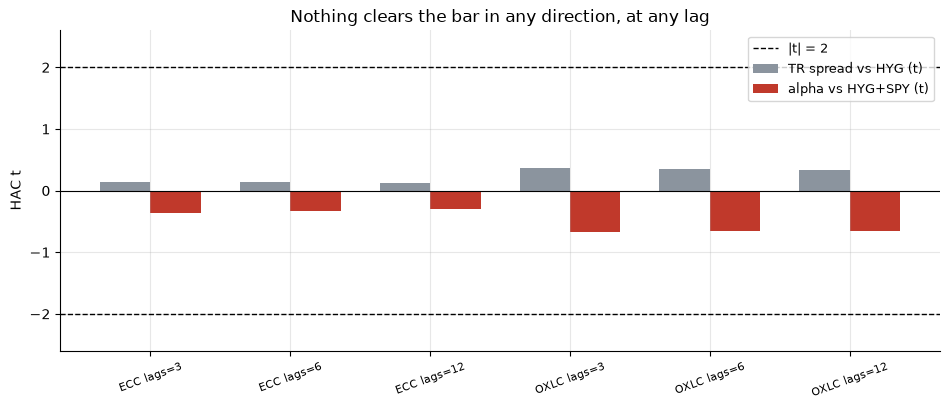

ECC lags=3    : spread t = +0.14 | alpha t = -0.36
ECC lags=6    : spread t = +0.13 | alpha t = -0.33
ECC lags=12   : spread t = +0.13 | alpha t = -0.30
OXLC lags=3   : spread t = +0.36 | alpha t = -0.67
OXLC lags=6   : spread t = +0.34 | alpha t = -0.66
OXLC lags=12  : spread t = +0.33 | alpha t = -0.65

2016-01+  ECC: dist +17.67%/yr (t +14.9) | TR +2.44%  PX -13.19%  | spread vs HYG t = +0.10 (n=126)
2016-01+ OXLC: dist +21.17%/yr (t +14.0) | TR +3.06%  PX -15.25%  | spread vs HYG t = +0.43 (n=126)
2020-07+  ECC: dist +19.86%/yr (t +11.1) | TR +7.98%  PX -10.23%  | spread vs HYG t = +0.43 (n=72)
2020-07+ OXLC: dist +21.04%/yr (t +9.7) | TR +5.30%  PX -13.25%  | spread vs HYG t = +0.34 (n=72)


In [4]:
if HAVE_REAL:
    rows = []
    for nm in ['ECC', 'OXLC']:
        mtr, _ = st.aligned_monthly(TR, PX, [nm, 'HYG', 'SPY', 'BIL'])
        for lags in (3, 6, 12):
            s = st.tr_spread_vs(mtr, nm, lags=lags)
            cp = st.carry_premium(mtr, nm, lags=lags)
            rows.append((f'{nm} lags={lags}', s['spread_t'], cp['t_alpha']))
else:
    rows = [(f'{nm} lags={l}', ts, ta) for nm in ['ECC', 'OXLC']
            for l, ts, ta in R['robust_lags'][nm]]
fig, ax = plt.subplots(figsize=(9.6, 4.2))
x = np.arange(len(rows))
ax.bar(x - .18, [r[1] for r in rows], .36, color=GREY, label='TR spread vs HYG (t)')
ax.bar(x + .18, [r[2] for r in rows], .36, color=RED, label='alpha vs HYG+SPY (t)')
ax.axhline(2, ls='--', c='k', lw=1, label='|t| = 2'); ax.axhline(-2, ls='--', c='k', lw=1)
ax.axhline(0, c='k', lw=.8)
ax.set_xticks(x); ax.set_xticklabels([r[0] for r in rows], fontsize=8, rotation=20)
ax.set_ylim(-2.6, 2.6); ax.set_ylabel('HAC t'); ax.legend(fontsize=9)
ax.set_title('Nothing clears the bar in any direction, at any lag')
plt.tight_layout(); plt.show()
for r in rows: print(f'{r[0]:<14}: spread t = {r[1]:+.2f} | alpha t = {r[2]:+.2f}')
print()
if HAVE_REAL:
    for lab, a in [('2016-01+', '2016-01-01'), ('2020-07+', '2020-07-01')]:
        sub_tr, sub_px = MTR.loc[a:], MPX.loc[a:]
        for nm in ['ECC', 'OXLC']:
            dd = st.decompose(sub_tr, sub_px, nm)
            s = st.tr_spread_vs(sub_tr, nm)
            print(f'{lab} {nm:>4}: dist {dd["dist_ann_pct"]:+.2f}%/yr (t {dd["dist_hac_t"]:+.1f}) | '
                  f'TR {dd["tr_cagr_pct"]:+.2f}%  PX {dd["px_cagr_pct"]:+.2f}%  | '
                  f'spread vs HYG t = {s["spread_t"]:+.2f} (n={s["n"]})')
else:
    for lab, sub in R['sub'].items():
        for nm, v in sub.items():
            print(f'{lab} {nm:>4}: dist {v[0]:+.2f}%/yr (t {v[1]:+.1f}) | TR {v[2]:+.2f}%  '
                  f'PX {v[3]:+.2f}%  | spread vs HYG t = {v[5]:+.2f} (n={v[6]})')

> 💡 In plain words: lags 3/6/12 move nothing (spread t stays at ~+0.1/+0.3, alpha t at ~−0.3/−0.7). Ex the 2015 entry, same picture. And in the post-COVID floating-rate regime — the sector's best-case marketing story — the payout hit ~20-21%/yr, TR improved to +8.0% / +5.3%/yr… and the price legs *still* eroded -10.2% / -13.2%/yr with the HYG spread still at t ≈ 0.4. The erosion is chronic, not one bad regime.

### 4d · Crisis autopsies — first-loss means first to fall

Peak-to-trough total-return drawdowns inside four fixed, documented windows. A genuine income sleeve should look like HYG's column. It looks like levered first-loss credit.

                        ECC  OXLC   HYG   SPY
crisis                                       
Credit crunch 2015-16 -29.7 -57.1 -13.4 -13.0
Q4 2018               -25.6 -23.4  -6.4 -19.3
COVID 2020            -66.1 -73.8 -22.0 -33.7
Rate shock 2022       -19.1 -36.8 -15.5 -24.5


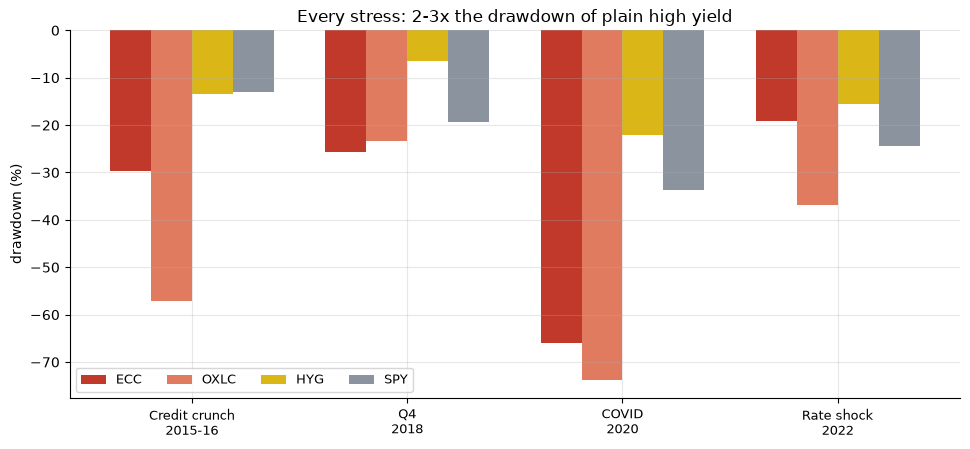

In [5]:
cols = ['ECC', 'OXLC', 'HYG', 'SPY']
if HAVE_REAL:
    ct = st.crisis_table(TR, cols)
else:
    ct = pd.DataFrame([c[1:] for c in R['crises']], columns=cols,
                      index=[c[0] for c in R['crises']])
print(ct.round(1).to_string())
fig, ax = plt.subplots(figsize=(9.8, 4.6))
x = np.arange(len(ct)); wdt = .19
shades = [RED, '#e07b5f', AMBER, GREY]
for k, (c, col) in enumerate(zip(cols, shades)):
    ax.bar(x + (k - 1.5) * wdt, ct[c].values, wdt, color=col, label=c)
ax.set_xticks(x); ax.set_xticklabels([i.replace(' 2', '\n2') for i in ct.index], fontsize=9)
ax.set_ylabel('drawdown (%)'); ax.legend(fontsize=9, ncol=4)
ax.set_title('Every stress: 2-3x the drawdown of plain high yield')
plt.tight_layout(); plt.show()

> 💡 In plain words: −66%/−74% in eight weeks in 2020 while HYG fell 22%; −57% for OXLC in the 2015-16 loan-spread blowout that cost HYG 13%. The equity tranche exists to absorb the pool's first losses so the AAAs never take one — in a repricing it is crossed out first, and the funds hold it with fund-level leverage on top. The coupon is crash insurance premium collected in reverse: it pays until the month you needed it not to.

### 4e · Faithful-engine control — we know the truth here

Deterministic factor world with planted `carry` and `alpha` knobs (seed 614). The null must stay silent; planted values must light up.

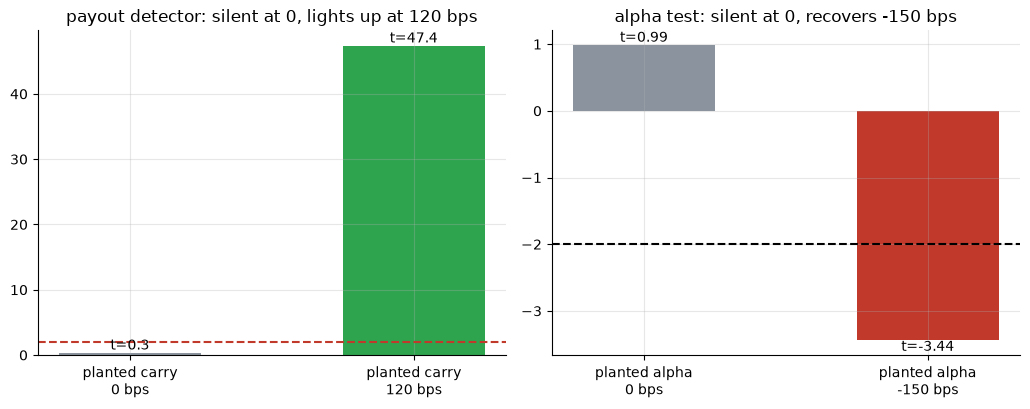

planted carry=  +0.0 alpha=  +0.0 bps/mo -> dist +0.85 (t +0.33) | alpha +33.40 (t +0.99)
planted carry=+120.0 alpha=-150.0 bps/mo -> dist +120.85 (t +47.36) | alpha -116.60 (t -3.44)


In [6]:
res = []
for carry, alpha in [(0.0, 0.0), (0.012, -0.015)]:
    ttr, tpx = data.synthetic_world(carry=carry, alpha=alpha, seed=614)
    smtr, smpx = st.aligned_monthly(ttr, tpx, ['CLOE', 'HYG', 'SPY', 'BIL'])
    sd = st.decompose(smtr, smpx, 'CLOE')
    scp = st.carry_premium(smtr, 'CLOE')
    res.append((carry * 1e4, alpha * 1e4, sd['dist_bps_mo'], sd['dist_hac_t'],
                scp['alpha_bps_mo'], scp['t_alpha']))
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.4, 4.2))
labels = [f'planted carry\n{r[0]:.0f} bps' for r in res]
a1.bar(labels, [r[3] for r in res], color=[GREY, GREEN], width=.5)
a1.axhline(2, ls='--', c=RED); a1.set_title('payout detector: silent at 0, lights up at 120 bps')
for i, r in enumerate(res): a1.annotate(f't={r[3]:.1f}', (i, r[3]), ha='center', va='bottom')
labels2 = [f'planted alpha\n{r[1]:.0f} bps' for r in res]
a2.bar(labels2, [r[5] for r in res], color=[GREY, RED], width=.5)
a2.axhline(-2, ls='--', c='k'); a2.set_title('alpha test: silent at 0, recovers -150 bps')
for i, r in enumerate(res): a2.annotate(f't={r[5]:.2f}', (i, r[5]), ha='center',
                                        va='top' if r[5] < 0 else 'bottom')
plt.tight_layout(); plt.show()
for r in res:
    print(f'planted carry={r[0]:+6.1f} alpha={r[1]:+6.1f} bps/mo -> '
          f'dist {r[2]:+.2f} (t {r[3]:+.2f}) | alpha {r[4]:+.2f} (t {r[5]:+.2f})')

> 💡 In plain words: under the (0, 0) null the detectors read t = +0.33 and +0.99 — no manufactured significance; the planted +120 bps payout and −150 bps alpha are recovered at t = 47.4 and -3.44, betas 1.45/0.41 vs planted 1.60/0.45. *(A machinery proof only — never cited in support of the real-tape stamps.)*

## 5 · The verdict

- **Signal `REAL`** — the payout exists and exceeds the pitch: ECC's distribution component is **+133.30 bps/mo (+17.22%/yr) at HAC t = +15.33**, OXLC's **+19.19%/yr at t = +15.35** — and the erosion financing it is on the same tape (price legs -13.46% / -14.38%/yr). What fails is the surplus: spread vs HYG t = +0.13 / +0.34. Survivorship named: no index fund exists; the category is its two survivors.
- **Tradability `MIRAGE`** — 11.7-15.4 years of harvest left TR CAGR at **+1.75% / +2.52%/yr** (excess over bills t = +0.43 / +0.81: cash, statistically) at 25-32% vol and **-59% / -61%** drawdowns, with no alpha vs a passive HYG+SPY mix whose copy compounded to +6.98% / +10.60%/yr at half the drawdown. Trading costs are irrelevant (~1.7 bps/yr); the 9-13%/yr wrapper drag is the mechanism.
- **Return OF capital? `CONFIRMED`** — **78.1%** (ECC) and **74.9%** (OXLC) of the distribution stream was offset one-for-one by price erosion; $100 of capital → **$18.5 / $9.1**. The market-price mirror of the funds' own 19(a) notices.

## 6 · Going further

- **The packaged-carry family.** [340 — Bank-Loans](../../340-bank-loans/README.md), [341 — MLP-Pipelines](../../341-mlp-pipelines/README.md), [342 — BDC-Yield](../../342-bdc-yield/README.md) and [611 — mREIT-Carry](../../611-mreit-carry/README.md) are the named siblings — same Real × Mirage pathology. This is the family's limit case: the coupon is the residual of a **first-loss tranche** (not a margin, not a toll), double-levered by the wrapper, with the biggest measured yield (17-19%/yr) and the starkest capital-consumption share (~75-78%).
- **What would change the verdict.** A NAV-based tape (the funds publish monthly NAV estimates) would split the price erosion into NAV erosion vs discount widening; institutional CLO-equity *held to maturity* (Cordell-Roberts-Schwert 2023) shows positive but dispersed economics — the gap between that and these tapes is the wrapper cost, and a cheap CLO-equity vehicle would be a different study.
- **The accounting cross-check.** Rule 19a-1 notices per distribution (both funds' sites) flag the return-of-capital share directly; our returns-arithmetic split is the market-price version and lands in the same place.

*The reproducible core is offline and deterministic; numbers frozen in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*